# Week 8 

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

In [2]:
from ipywidgets import interact, fixed

In [11]:
def f(n, m=2):
    print(f"{n}^{m} = {n**m}")

interact(f, n=(0, 10), m=fixed(2));

interactive(children=(IntSlider(value=5, description='n', max=10), Output()), _dom_classes=('widget-interact',…

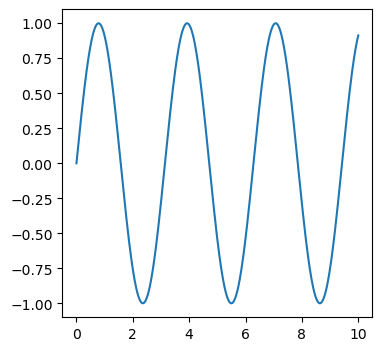

In [9]:
def plot(n):
    plt.figure(figsize=(4, 4))
    x = np.linspace(0, 10, 500)
    plt.plot(x, np.sin(n*x))
    plt.show()

plot(2)

In [10]:
interact(plot, n=(1, 10));

interactive(children=(IntSlider(value=5, description='n', max=10, min=1), Output()), _dom_classes=('widget-int…

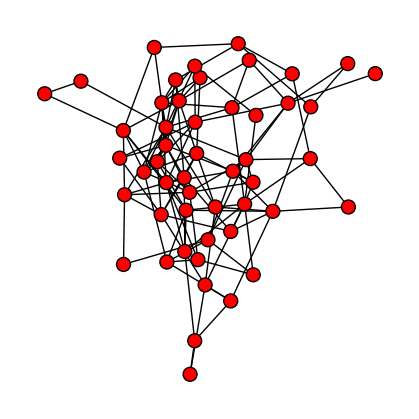

In [18]:
def random_graph(n, d):
    """
    Returns the adjacency matrix of a random graph 
    with n vertices and with expected vertex degree d.
    """
    p = d/(n-1)
    rng = np.random.default_rng()
    a = np.zeros((n, n), dtype=int)
    selection = (rng.random((n, n)) < p)
    a[selection] = 1
    b = np.triu(a, k=1)
    adj = b + b.T
    return adj


def plot_graph(adj, r=0):
    G = nx.from_numpy_array(adj)
    pos = nx.spring_layout(G, seed=0)
    node_color = ["red"]*r + ["green"]*(adj.shape[0] - r)
    plt.figure(figsize=(4, 4))
    nx.draw(G, 
            pos=pos,
            node_color=node_color,
            edgecolors="black",
            node_size=100,    
    )
    plt.show()

adj = random_graph(50, 5)
plot_graph(adj, r=50)

In [20]:
interact(plot_graph, adj=fixed(adj), r=(0, 50));

interactive(children=(IntSlider(value=0, description='r', max=50), Output()), _dom_classes=('widget-interact',…

## Visualizing epidemic

In [21]:
rng = np.random.default_rng()

arr = rng.integers(0, 3, (100, 50))
arr

array([[0, 0, 1, ..., 0, 1, 2],
       [0, 2, 2, ..., 2, 2, 2],
       [0, 1, 0, ..., 2, 0, 2],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 2, 1, ..., 2, 2, 2],
       [2, 0, 0, ..., 0, 1, 0]], shape=(100, 50))

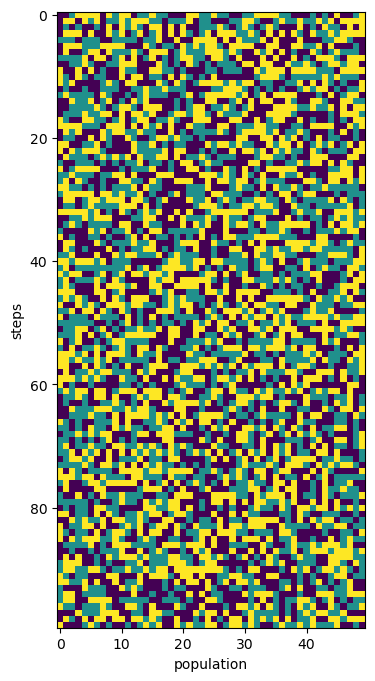

In [23]:
plt.figure(figsize=(6, 8))
plt.imshow(arr)
plt.ylabel("steps")
plt.xlabel("population")
plt.show()

In [24]:
from matplotlib.colors import ListedColormap

colors = ["green", "red", "gold"]
mycmap = ListedColormap(colors)


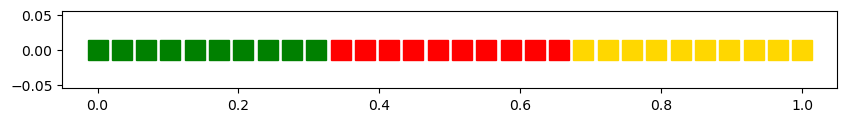

In [25]:
x = np.linspace(0, 1, 30)
plt.figure(figsize=(10, 1))
for i in x:
    plt.plot(i, 0, marker='s', ms=15, color=mycmap(i))
plt.show()


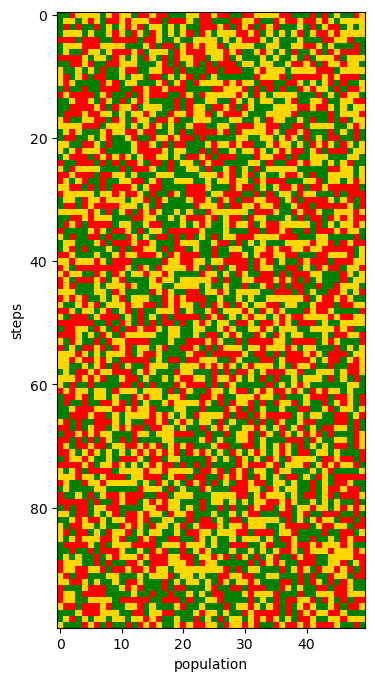

In [27]:
plt.figure(figsize=(6, 8))
plt.imshow(arr, cmap=mycmap)
plt.ylabel("steps")
plt.xlabel("population")
plt.show()

In [28]:
arr

array([[0, 0, 1, ..., 0, 1, 2],
       [0, 2, 2, ..., 2, 2, 2],
       [0, 1, 0, ..., 2, 0, 2],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 2, 1, ..., 2, 2, 2],
       [2, 0, 0, ..., 0, 1, 0]], shape=(100, 50))

In [30]:
(arr == 0).sum(axis=1)

array([16, 11, 20, 14, 19, 16, 14, 17, 17, 17, 18, 18, 18, 15, 22, 14, 15,
       20, 14, 16, 23, 17, 16, 16, 20, 21, 17, 17, 15, 15, 13, 14, 13, 16,
       15, 19, 21, 17, 17, 15, 12, 12, 18, 16, 22, 19, 16, 12, 18, 11, 15,
       16, 17, 17, 16, 13, 12, 16, 15, 17, 28, 13, 16, 18, 20, 13, 21, 16,
       17, 24, 15, 15, 17, 13, 15, 12, 17, 23, 15, 18, 17, 20, 16, 12, 18,
       18, 13, 19, 13, 18, 10, 21, 21, 23, 21, 18, 19, 17, 17, 15])

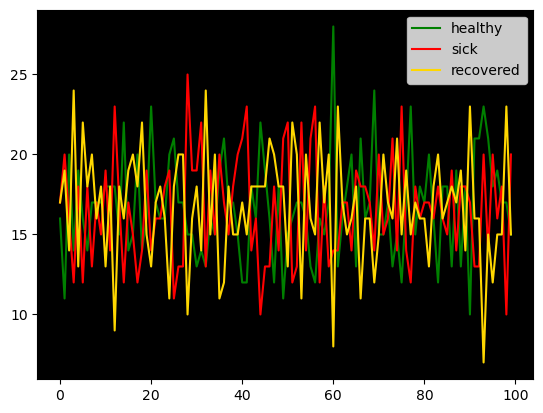

In [34]:
healthy = (arr == 0).sum(axis=1)
sick = (arr == 1).sum(axis=1)
recovered = (arr == 2).sum(axis=1)

plt.gca().set_facecolor("black")
plt.plot(healthy, color="green", label="healthy")
plt.plot(sick, color="red", label="sick")
plt.plot(recovered, color="gold", label="recovered")
plt.legend()
plt.show()

In [35]:
healthy = (arr == 0).sum(axis=1)/arr.shape[1]

In [36]:
healthy

array([0.32, 0.22, 0.4 , 0.28, 0.38, 0.32, 0.28, 0.34, 0.34, 0.34, 0.36,
       0.36, 0.36, 0.3 , 0.44, 0.28, 0.3 , 0.4 , 0.28, 0.32, 0.46, 0.34,
       0.32, 0.32, 0.4 , 0.42, 0.34, 0.34, 0.3 , 0.3 , 0.26, 0.28, 0.26,
       0.32, 0.3 , 0.38, 0.42, 0.34, 0.34, 0.3 , 0.24, 0.24, 0.36, 0.32,
       0.44, 0.38, 0.32, 0.24, 0.36, 0.22, 0.3 , 0.32, 0.34, 0.34, 0.32,
       0.26, 0.24, 0.32, 0.3 , 0.34, 0.56, 0.26, 0.32, 0.36, 0.4 , 0.26,
       0.42, 0.32, 0.34, 0.48, 0.3 , 0.3 , 0.34, 0.26, 0.3 , 0.24, 0.34,
       0.46, 0.3 , 0.36, 0.34, 0.4 , 0.32, 0.24, 0.36, 0.36, 0.26, 0.38,
       0.26, 0.36, 0.2 , 0.42, 0.42, 0.46, 0.42, 0.36, 0.38, 0.34, 0.34,
       0.3 ])

## Strings

In [37]:
s = "University at Buffalo"

In [38]:
len(s)

21

In [39]:
for c in s:
    print(c)

U
n
i
v
e
r
s
i
t
y
 
a
t
 
B
u
f
f
a
l
o


In [40]:
s[0]

'U'

In [41]:
s[1]

'n'

In [42]:
s[-1]

'o'

In [43]:
s[5:10]

'rsity'

In [45]:
s2 = " SUNY"
t = s + s2
print(t)

University at Buffalo SUNY


In [46]:
print(s*3)

University at BuffaloUniversity at BuffaloUniversity at Buffalo


In [47]:
s[0] = "X"

TypeError: 'str' object does not support item assignment

In [48]:
t = "X" + s[1:]
print(t)

Xniversity at Buffalo


"\n" is a new line character:

In [53]:
s = "University at Buffalo\nSUNY"
print(s)

University at Buffalo
SUNY


"\t" - the tab character

In [55]:
s = "University at Buffalo\tSUNY"
print(s)

University at Buffalo	SUNY


Unicode characters:

In [57]:
print("Hello \U0001F60D")

Hello 😍


In [58]:
s

'University at Buffalo\tSUNY'

In [59]:
s.lower()

'university at buffalo\tsuny'

In [60]:
s.upper()

'UNIVERSITY AT BUFFALO\tSUNY'

In [61]:
s.split()

['University', 'at', 'Buffalo', 'SUNY']

In [62]:
s.split("si")

['Univer', 'ty at Buffalo\tSUNY']

In [63]:
words = s.split()
words

['University', 'at', 'Buffalo', 'SUNY']

In [64]:
"_".join(words)

'University_at_Buffalo_SUNY'

In [65]:
"-SPACE-".join(words)

'University-SPACE-at-SPACE-Buffalo-SPACE-SUNY'

In [66]:
s

'University at Buffalo\tSUNY'

In [68]:
t = s.replace('a', "AAA")
print(t)

University AAAt BuffAAAlo	SUNY


In [69]:
s.replace("at", "of")

'University of Buffalo\tSUNY'

In [70]:
"at" in s

True

In [71]:
"of" in s

False

In [72]:
s.find("at")

11

In [73]:
s[11:]

'at Buffalo\tSUNY'

In [74]:
s.find("of")

-1

In [75]:
w = "   hello !    "

In [76]:
w.strip()

'hello !'

In [1]:
text = 'This is some text'

In [2]:
with open('OurFile.txt','w') as f:
    f.write(text)

In [3]:
f.write('Try writing some more')

ValueError: I/O operation on closed file.

In [4]:
with open('OurFile.txt','r') as File:
    contents = File.read()

In [5]:
print(contents)

This is some text


In [6]:
with open('OurFile.txt','r') as File:
    File.write('bla bla bla')

UnsupportedOperation: not writable

In [7]:
with open('OurFile.txt','w') as f:
    f.write('Some more text')

In [8]:
with open('OurFile.txt','r') as f:
    print(f.read())

Some more text


In [9]:
with open('OurFile.txt','a') as f:
    f.write('More text')

In [10]:
with open('OurFile.txt','r') as f:
    print(f.read())

Some more textMore text


In [11]:
with open('OurFile.txt','a') as f:
    f.write('\n THis is a new line')
    f.write('\n\t This is a new line and its tabed')

In [12]:
with open('OurFile.txt','r') as f:
    print(f.read())

Some more textMore text
 THis is a new line
	 This is a new line and its tabed


In [13]:
book_url = 'https://www.gutenberg.org/cache/epub/5658/pg5658.txt'

In [14]:
import requests

In [15]:
response = requests.get(book_url)

In [16]:
response.headers

{'date': 'Wed, 18 Mar 2026 14:32:31 GMT', 'server': 'Apache', 'last-modified': 'Tue, 03 Mar 2026 10:15:02 GMT', 'accept-ranges': 'bytes', 'content-length': '751825', 'x-backend': 'gutenweb1', 'content-type': 'text/plain; charset=utf-8'}

In [17]:
response.status_code

200

In [18]:
book = response.text

In [19]:
book[10000:15000]

'd to the family for\r\ngenerations; but Jim was one of five sons, and when after a course of\r\nlight holiday literature his vocation for the sea had declared itself,\r\nhe was sent at once to a ‘training-ship for officers of the mercantile\r\nmarine.’\r\n\r\nHe learned there a little trigonometry and how to cross top-gallant\r\nyards. He was generally liked. He had the third place in navigation\r\nand pulled stroke in the first cutter. Having a steady head with an\r\nexcellent physique, he was very smart aloft. His station was in the\r\nfore-top, and often from there he looked down, with the contempt of a\r\nman destined to shine in the midst of dangers, at the peaceful multitude\r\nof roofs cut in two by the brown tide of the stream, while scattered\r\non the outskirts of the surrounding plain the factory chimneys rose\r\nperpendicular against a grimy sky, each slender like a pencil, and\r\nbelching out smoke like a volcano. He could see the big ships departing,\r\nthe broad-beamed 

In [20]:
print('AAAAA\rBB')

BBAAA


In [21]:
len(book)

740853

In [24]:
print(book[10000:11000])

d to the family for
generations; but Jim was one of five sons, and when after a course of
light holiday literature his vocation for the sea had declared itself,
he was sent at once to a ‘training-ship for officers of the mercantile
marine.’

He learned there a little trigonometry and how to cross top-gallant
yards. He was generally liked. He had the third place in navigation
and pulled stroke in the first cutter. Having a steady head with an
excellent physique, he was very smart aloft. His station was in the
fore-top, and often from there he looked down, with the contempt of a
man destined to shine in the midst of dangers, at the peaceful multitude
of roofs cut in two by the brown tide of the stream, while scattered
on the outskirts of the surrounding plain the factory chimneys rose
perpendicular against a grimy sky, each slender like a pencil, and
belching out smoke like a volcano. He could see the big ships departing,
the broad-beamed ferries constantly on the move, t


In [25]:
img_url = 'https://cdn.jsdelivr.net/gh/bbadzioch/mth337_site@main/schedule/week4/circuit.png'

In [ ]:
resp_img = requests.get(img_url)
img = resp_img.content

with open('OurImage.png','wb') as f:
    f.write(img)

In [27]:
import string

In [28]:
string.ascii_letters

'abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ'

In [29]:
string.ascii_lowercase

'abcdefghijklmnopqrstuvwxyz'

In [30]:
string.ascii_uppercase

'ABCDEFGHIJKLMNOPQRSTUVWXYZ'

In [31]:
OurSet = {1,2,3,4,4,4}

In [32]:
OurSet

{1, 2, 3, 4}

In [33]:
len(OurSet)

4

In [34]:
1 in OurSet

True

In [35]:
5 in OurSet

False

In [36]:
for i in range(5):
    print(i)
    #same in operation

0
1
2
3
4


In [37]:
A = {1,2,3}
B = {3,4,5}

In [ ]:
C = A | B
print(C)

{1, 2, 3, 4, 5}


In [41]:
D = A & B
print(D)

{3}


In [42]:
E = A-B
print(E)

{1, 2}


In [43]:
MyList = [1,2,3,4,3,2,1]

In [44]:
MySet = set(MyList)

In [45]:
MySet

{1, 2, 3, 4}

In [46]:
MySet[2]

TypeError: 'set' object is not subscriptable

In [47]:
Empty = set()

In [48]:
Empty

set()

In [49]:
Empty.add(1)
print(Empty)

{1}


In [50]:
print(MySet)
MySet.remove(3)
print(MySet)

{1, 2, 3, 4}
{1, 2, 4}


In [51]:
score = {'Gatsby':97,'Daisy':99,'Myrtle':85}

In [52]:
score['Gatsby']

97

In [55]:
score['Daisy'] = 100

In [56]:
score

{'Gatsby': 97, 'Daisy': 100, 'Myrtle': 85}

In [57]:
score['Myrtle'] = 90

In [58]:
score

{'Gatsby': 97, 'Daisy': 100, 'Myrtle': 90}

In [59]:
score['Pierre'] = 77

In [60]:
score

{'Gatsby': 97, 'Daisy': 100, 'Myrtle': 90, 'Pierre': 77}

In [61]:
'Gatsby' in score

True

In [62]:
'Leo' in score

False

In [63]:
100 in score

False

In [64]:
for key in score:
    print('Key:',key,' value:', score[key])

Key: Gatsby  value: 97
Key: Daisy  value: 100
Key: Myrtle  value: 90
Key: Pierre  value: 77


In [65]:
for val in score.values():
    print(val)

97
100
90
77


In [66]:
score.values()

dict_values([97, 100, 90, 77])

In [67]:
score.items()

dict_items([('Gatsby', 97), ('Daisy', 100), ('Myrtle', 90), ('Pierre', 77)])

In [68]:
emptydict = {}

In [69]:
emptydict[3] = 'Three'

In [70]:
emptydict

{3: 'Three'}

In [71]:
phrase = 'some words in a row'

In [72]:
phrase.split()

['some', 'words', 'in', 'a', 'row']